# Logistic Regression
First, we import the necessary libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

### Load the data

In [2]:
train_df = pd.read_csv('data/splits/TRAIN_LJ_Dataset.csv')
val_df = pd.read_csv('data/splits/VALID_LJ_Dataset.csv')
test_df = pd.read_csv('data/splits/TEST_LJ_Dataset_w_HSG.csv')

train_df.head()

,Date,Age,Home,HSG,PPG3,3PA3,3P%3,FGA3,FG%3,FTA3,FT%3,MP3
0,2003-11-05,18.849315,1,0,18.000,2.667,0.067,16.333,0.440,4.000,0.635,40.783
1,2003-11-07,18.854795,0,0,12.000,2.667,0.067,13.333,0.331,3.333,0.857,40.206
2,2003-11-08,18.857534,1,0,12.667,1.667,0.167,13.667,0.322,3.333,0.952,41.333
3,2003-11-10,18.863014,1,0,15.667,1.333,0.167,16.000,0.379,4.000,0.702,43.111
4,2003-11-12,18.868493,0,0,19.000,1.667,0.500,16.333,0.483,3.667,0.369,40.628


### Separate features and target

We drop `Date` because it is just an identifier and not a useful feature for the model. `HSG` is separated as the target variable.

In [3]:
drop_cols = ['Date', 'HSG']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['HSG']

X_val = val_df.drop(columns=drop_cols)
y_val = val_df['HSG']

X_test = test_df.drop(columns=drop_cols)
y_test = test_df['HSG']

### Addressing class imbalance through SMOTE

Looking at the dataset below, we can see that there is a mild class imbalance between `HSG=1` and `HSG=0`. Class imbalance may negatively affect model training because the classifier can become biased toward predicting the majority class, potentially reducing its ability to correctly identify instances of the minority class. 

With this, we implement SMOTE (Synthetic Minority Oversampling Technique) to the training set by generating synthetic samples for the minority class (Not High-Scoring). This is applied only to the training set to avoid data leakage.

In [4]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=1)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("After SMOTE:", pd.Series(y_train_resampled).value_counts().to_dict())

Before SMOTE: {1: 620, 0: 372}
After SMOTE: {0: 620, 1: 620}


Both classes now have an equal number of instances. Let's proceed with the next step of the pipeline!

### Feature scaling

Scaling puts all features on the same numerical range. Right now our features have very different scales. For example, `MP3` has values around 38, `PPG3` around 27, but `FG%3` is between 0 and 1.

This matters because logistic regression learns by adjusting weights for each feature. If one feature has much larger values than another, the model may treat it as more important simply because of its scale, not because it actually is more important.

`StandardScaler` specifically transforms each feature so that it has a mean of 0 and a standard deviation of 1, making them all comparable.

`fit_tranform` computes the mean and standard deviation from the training data, then applies the transformation. For val and test, we only call transform, meaning we reuse the stats learned from the training data. This is important because in a real scenario we wouldn't have access to val/test data ahead of time, so we can't let their values influence the scaling.

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_resampled)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

We have now scaled the features on the SMOTE-resampled training set. Here are the new values:

In [6]:
pd.DataFrame(X_train_scaled, columns=X_train_resampled.columns).head()

,Age,Home,PPG3,3PA3,3P%3,FGA3,FG%3,FTA3,FT%3,MP3
0,-1.639664,1.080663,-1.805153,-0.858844,-1.580536,-1.031707,-0.800812,-1.552631,-0.874153,0.534721
1,-1.638226,-0.925358,-3.001629,-0.858844,-1.580536,-1.962822,-2.281362,-1.795899,1.135833,0.370118
2,-1.637507,1.080663,-2.868621,-1.510314,-0.889882,-1.859158,-2.403609,-1.795899,1.995962,0.691622
3,-1.636070,1.080663,-2.270383,-1.727906,-0.889882,-1.135061,-1.629377,-1.552631,-0.267535,1.198839
4,-1.634632,-0.925358,-1.605740,-1.510314,1.409996,-1.031707,-0.216743,-1.674083,-3.282514,0.490503


In [7]:
# Sanity check
pd.DataFrame(X_train_scaled, columns=X_train_resampled.columns).describe()

,Age,Home,PPG3,3PA3,3P%3,FGA3,FG%3,FTA3,FT%3,MP3
count,1240.000000,1.240000e+03,1.240000e+03,1.240000e+03,1.240000e+03,1.240000e+03,1.240000e+03,1240.000000,1.240000e+03,1.240000e+03
mean,0.000000,-9.168293e-17,2.292073e-16,-2.292073e-16,-2.177470e-16,-6.417805e-16,-7.334635e-16,0.000000,8.423370e-16,1.398165e-15
std,1.000403,1.000403e+00,1.000403e+00,1.000403e+00,1.000403e+00,1.000403e+00,1.000403e+00,1.000403,1.000403e+00,1.000403e+00
min,-1.639664,-9.253580e-01,-3.400454e+00,-2.596316e+00,-2.043275e+00,-2.686918e+00,-3.463084e+00,-2.525341,-4.613451e+00,-3.671363e+00
25%,-0.827094,-9.253580e-01,-6.750812e-01,-6.419037e-01,-7.034054e-01,-7.213354e-01,-5.970672e-01,-0.701737,-5.134730e-01,-6.922437e-01
50%,-0.020275,-9.253580e-01,1.646030e-02,9.567215e-03,-1.571574e-02,-2.519985e-02,-8.091243e-02,-0.027726,7.468156e-02,4.031255e-02
75%,0.826436,1.080663e+00,6.542038e-01,6.610381e-01,6.433702e-01,6.238149e-01,6.254046e-01,0.757146,6.378636e-01,7.063022e-01
max,1.775931,1.080663e+00,3.180164e+00,4.352924e+00,3.709875e+00,3.727530e+00,3.898912e+00,2.945470,2.430554e+00,2.858280e+00


### Building and training the logistic regression model
We use `LogisticRegression` with L2 regularization. L2 is preferred over L1 here because most features carry some signal and our features are correlated with each other, making L2's weight-shrinking approach more appropriate than L1's feature elimination. `C=1.0` is the default starting value for regularization strength and will be tuned in a later step.

In [8]:
# Instantiate the model
model_lr = LogisticRegression(
    penalty='l2',
    C=1.0,
    max_iter=200,
    random_state=1
)

# Train the model
model_lr.fit(X_train_scaled, y_train_resampled)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,1
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


### Evaluate the model on the validation set

It is important to note that SMOTE is applied only to the training set. The validation set remains unchanged to ensure that model evaluation reflects performance on real and unseen data.

Validation Accuracy: 0.4811320754716981

Classification Report:
                  precision    recall  f1-score   support

Not High-Scoring       0.38      0.70      0.49        76
    High-Scoring       0.68      0.36      0.47       136

        accuracy                           0.48       212
       macro avg       0.53      0.53      0.48       212
    weighted avg       0.57      0.48      0.48       212



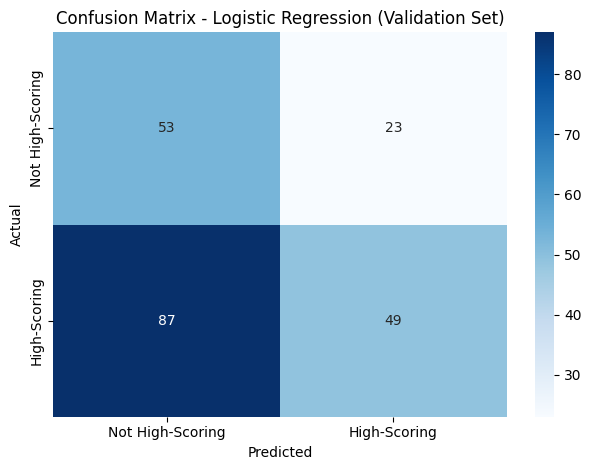

In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on validation data
y_val_pred = model_lr.predict(X_val_scaled)

# Accuracy
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))

# Detailed metrics
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=['Not High-Scoring', 'High-Scoring']))

# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not High-Scoring', 'High-Scoring'],
            yticklabels=['Not High-Scoring', 'High-Scoring'])

plt.title("Confusion Matrix - Logistic Regression (Validation Set)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

### Tune the regularization strength (C)

The confusion matrix shows that the model tends to favor predicting the Not High-Scoring class, resulting in a high number of misclassified High-Scoring instances.

We try different values of `C` to find the best balance between underfitting and overfitting. Since `C` is the inverse of regularization strength, smaller values mean stronger regularization and larger values mean weaker regularization. For each value of C, the logistic regression model is trained on the SMOTE-resampled and scaled training set, then evaluated on the validation set.

In [10]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression

for C in [0.001, 0.01, 0.1, 1.0, 10, 100]:
    
    m = LogisticRegression(
        penalty='l2',
        C=C,
        max_iter=200,
        random_state=1
    )
    
    # Train on SMOTE + scaled data
    m.fit(X_train_scaled, y_train_resampled)
    
    # Predict on validation set
    preds = m.predict(X_val_scaled)
    
    acc = accuracy_score(y_val, preds)
    macro_f1 = f1_score(y_val, preds, average='macro')
    
    print(f"C={C} | Accuracy: {acc:.4f} | Macro F1: {macro_f1:.4f}")

C=0.001 | Accuracy: 0.4717 | Macro F1: 0.4713
C=0.01 | Accuracy: 0.4623 | Macro F1: 0.4623
C=0.1 | Accuracy: 0.4717 | Macro F1: 0.4717
C=1.0 | Accuracy: 0.4811 | Macro F1: 0.4809
C=10 | Accuracy: 0.4858 | Macro F1: 0.4857
C=100 | Accuracy: 0.4858 | Macro F1: 0.4857


`C=10` is selected because it achieved the highest validation accuracy and macro F1, while being the smaller value among the tied candidates.

### Retraining the final model

After selecting the best `C` value, we retrain the model using it.

In [11]:
final_model_lr = LogisticRegression(
    penalty='l2',
    C=10,
    max_iter=200,
    random_state=1
)

final_model_lr.fit(X_train_scaled, y_train_resampled)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,1
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [12]:
y_val_pred_final = final_model_lr.predict(X_val_scaled)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred_final))
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_final, target_names=['Not High-Scoring', 'High-Scoring']))

Validation Accuracy: 0.4858490566037736

Classification Report:
                  precision    recall  f1-score   support

Not High-Scoring       0.38      0.70      0.49        76
    High-Scoring       0.68      0.37      0.48       136

        accuracy                           0.49       212
       macro avg       0.53      0.53      0.49       212
    weighted avg       0.58      0.49      0.48       212



### Tune the decision threshold

The current model shows limited performance on the validation set, particularly in identifying High-Scoring instances, with a recall of only 37%. To improve the balance between precision and recall, the decision threshold is tuned instead of keeping the default value of 0.5.

In [13]:
probs = final_model_lr.predict_proba(X_val_scaled)[:,1]

thresholds = np.arange(0.3, 0.7, 0.05)
best_t, best_f1 = 0.5, 0

for t in thresholds:
    preds = (probs >= t).astype(int)
    f1 = f1_score(y_val, preds, average='macro')
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Best Macro F1:", best_f1)

Best threshold: 0.44999999999999996
Best Macro F1: 0.5460169410868945


### Evaluate on validation set (threshold tuned)

In [14]:
y_val_pred_thresh = (probs >= best_t).astype(int)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred_thresh))
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_thresh, target_names=['Not High-Scoring', 'High-Scoring']))

Validation Accuracy: 0.5754716981132075

Classification Report:
                  precision    recall  f1-score   support

Not High-Scoring       0.41      0.45      0.43        76
    High-Scoring       0.68      0.65      0.66       136

        accuracy                           0.58       212
       macro avg       0.55      0.55      0.55       212
    weighted avg       0.58      0.58      0.58       212



### Evaluate on test set

In [17]:
probs_test = final_model_lr.predict_proba(X_test_scaled)[:,1]
y_test_pred = (probs_test >= best_t).astype(int)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Not High-Scoring', 'High-Scoring']))

Test Accuracy: 0.5654205607476636

Classification Report:
                  precision    recall  f1-score   support

Not High-Scoring       0.41      0.53      0.46        76
    High-Scoring       0.69      0.59      0.64       138

        accuracy                           0.57       214
       macro avg       0.55      0.56      0.55       214
    weighted avg       0.59      0.57      0.57       214



### Confusion matrix

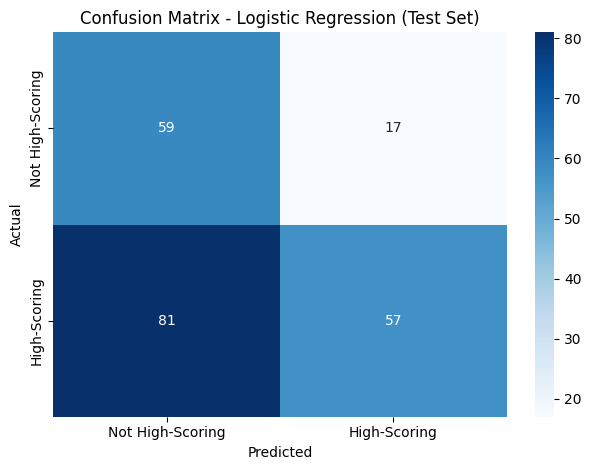

In [16]:
cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not High-Scoring', 'High-Scoring'],
            yticklabels=['Not High-Scoring', 'High-Scoring'])

plt.title("Confusion Matrix - Logistic Regression (Test Set)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

### Conclusions